In [1]:
#Carguemos el dataset para empezar a trabajar con los pokemon!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
data = pd.read_csv("pokemon-data.csv")

In [2]:
#Verificamos que esta todo cargado correctamente
data.head()

,Pokedex No.,Name,Type,Other Type,HP,Attack,Defense,Special Attack,Special Defense,Speed,Total,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,318,1,0
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,405,1,0
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,525,1,0
3,3,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,625,1,0
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,309,1,0


In [3]:
#Vemos que hay muchos nulos, pero no es que sean valores nulos, el tema es que hay 492 pokemon que no tienen un segundo tipo, es decir son monotype (solo tienen un tipo).
data.isnull().sum()

Pokedex No.          0
Name                 0
Type                 0
Other Type         492
HP                   0
Attack               0
Defense              0
Special Attack       0
Special Defense      0
Speed                0
Total                0
Generation           0
Legendary            0
dtype: int64

In [4]:
#Para arreglar esto, pondremos "none" en los pokemon sin segundo tipo:
data["Other Type"] = data["Other Type"].fillna("None")
data.isnull().sum()

Pokedex No.        0
Name               0
Type               0
Other Type         0
HP                 0
Attack             0
Defense            0
Special Attack     0
Special Defense    0
Speed              0
Total              0
Generation         0
Legendary          0
dtype: int64

In [5]:
#Vemos que ya solucionamos el problema, algo que queremos estudiar ahora es si realmente existe algun tipo de relacion entre el numero total de stats y el tipo del pokemon, por lo que para ello compararemos el "Total" con cada tipo:
#Para ello haremos un melt para que no se cuenten dos veces y quede una sola columna none al hacer el boxplot (Cabe mencionar que al no saber como hacerlo, en este punto se requirió ayuda de IA generativa describiendo lo que se quería lograr).
df_largo = data.melt(
    id_vars=['Name', 'Total'], 
    value_vars=['Type', 'Other Type'], #Las dos columnas de tipos
    value_name='Tipo_Individual'
)
df_largo = df_largo[df_largo['Tipo_Individual'] != 'None']
df_largo.head()

,Name,Total,variable,Tipo_Individual
0,Bulbasaur,318,Type,Grass
1,Ivysaur,405,Type,Grass
2,Venusaur,525,Type,Grass
3,Mega Venusaur,625,Type,Grass
4,Charmander,309,Type,Fire


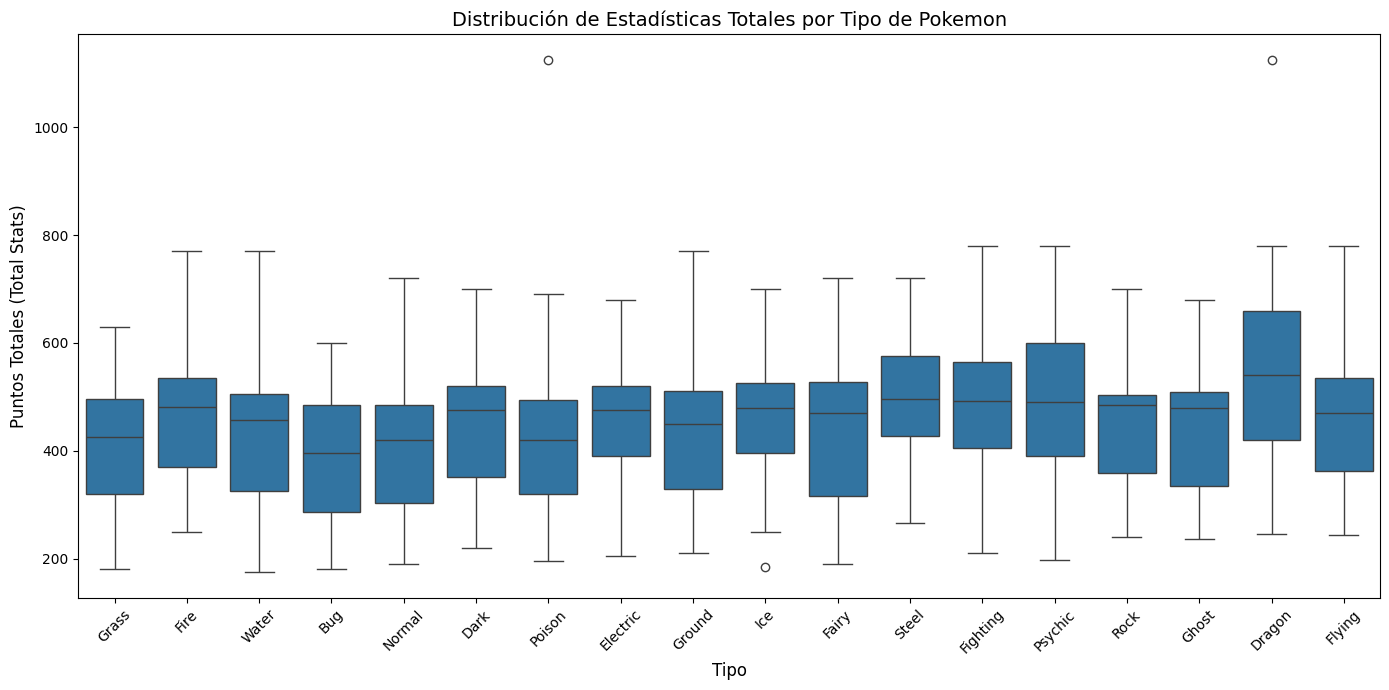

In [6]:
#Teniendo lo anterior listo hacemos el boxplot
plt.figure(figsize=(14, 7))
sns.boxplot(x='Tipo_Individual', y='Total', data=df_largo)
plt.title('Distribución de Estadísticas Totales por Tipo de Pokemon', fontsize=14)
plt.xlabel('Tipo', fontsize=12)
plt.ylabel('Puntos Totales (Total Stats)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
#Si queremos saber cuales son esos grandes outliers o el pequeño de "Ice", podemos usar el siguiente filtro, en donde cambianes el Tipo individual para saber y el total sea mayor, menor, etc:
outliers_rapidos = df_largo[(df_largo['Tipo_Individual'] == 'Ice') & (df_largo['Total'] < 200)]
print(outliers_rapidos[['Name', 'Total', 'Tipo_Individual']])

      Name  Total Tipo_Individual
1009  Snom    185             Ice


In [8]:
#Vemos que el pokemon con mas stats, se repite, es eternatus eternamax, y el con menos snom (destacar que ademas de tener unas stats absurdas, tambien es legendario).
#Ahora no menos importante queremos formar un equipo de 6, para nuestro juego, por lo que tenemos que tener en cuenta que no se pueden repetir pokemon ni pueden ser legendarios (Legendary = 0, no es legendario; Legendary = 1, es legendario).
#Para ello vamos a sacar los legendarios, ordenarlos de mayor a menor con sus stats y eliminaremos los tipos repetidos:
df_comunes = data[data['Legendary'] == 0]
df_ordenado = df_comunes.sort_values(by='Total', ascending=False)
mejores_por_tipo = df_ordenado.drop_duplicates(subset=['Type'], keep='first')
equipo_ideal = mejores_por_tipo.head(6)

In [9]:
#Ahora mostramos nuestro equipo basado solo en stats:
print(equipo_ideal[['Name', 'Type', 'Other Type', 'Total']])

                 Name    Type Other Type  Total
532     Mega Garchomp  Dragon     Ground    700
451    Mega Metagross   Steel    Psychic    700
301    Mega Tyranitar    Rock       Dark    700
348           Slaking  Normal       None    670
168     Mega Gyarados   Water       Dark    640
7    Mega Charizard X    Fire     Dragon    634


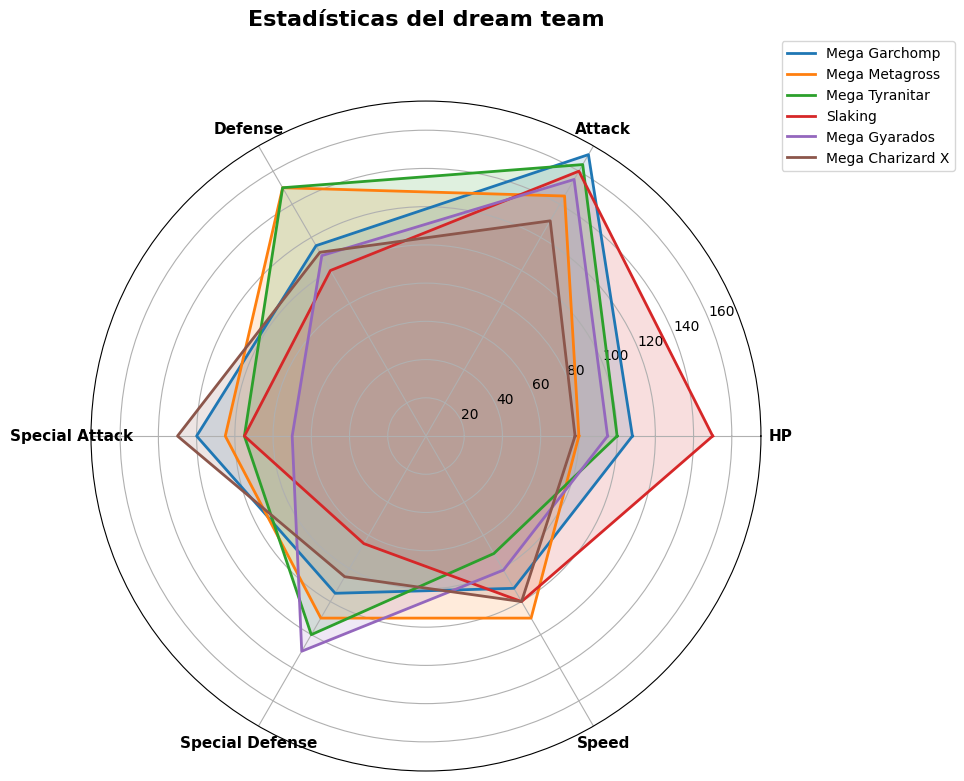

In [10]:
#Ahora para ir un poco de la mano con lo que es pokemon, haremos un radar chart para ver como se distribuyen las estaditiscas de cada uno del dream team:
atributos = ['HP', 'Attack', 'Defense', 'Special Attack', 'Special Defense', 'Speed']
num_vars = len(atributos)
#Ahora calculamos cada "punta" de la telaraña/radar:
angulos = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angulos += angulos[:1] #Repetimos el primer ángulo al final para cerrar el círculo

#Con ayuda de Gemini, descubri que se puede usar polar para que esto no se vea "deforme", logrando que el espacio en el que se mueven los datos sea un circulo!
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

#Iteramos para todos los pokemon del equipo y usamos un ciclo for para que dibuje una capa sobre otra:
for i, fila in equipo_ideal.iterrows():
    #Sacamos los valores de las stats para este pokemon específico
    valores = fila[atributos].values.flatten().tolist()
    valores += valores[:1] #Repetimos el primer valor para cerrar la figura
    
    #Dibujamos la línea y rellenamos el interior con un poco de transparencia (alpha)
    ax.plot(angulos, valores, linewidth=2, linestyle='solid', label=fila['Name'])
    ax.fill(angulos, valores, alpha=0.15)

plt.xticks(angulos[:-1], atributos, size=11, fontweight='bold')
#Ajustamos la posición de la leyenda por si a caso para que no tape el gráfico
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.title('Estadísticas del dream team', size=16, fontweight='bold', y=1.1)
plt.tight_layout()
plt.show()

In [11]:
#El dataset tiene 1045 filas (898 pokemon base + formas alternativas incluyendo megas).
#Eliminamos las megas porque tienen stats infladas artificialmente que sesgarían el modelo.
df_limpio = data[~data['Name'].str.contains('Mega', na=False)].copy()
#Además, hay formas alternativas como las alola o las galar, que si bien no inflan stats ni introducen sesgo, sí duplican pokemon (por ejemplo, hay un Vulpix normal y un Vulpix Alola, ambos con el mismo número de Pokédex pero diferentes tipos).
#Por lo que también sacaremos las formas alternativas para quedarnos solo con un pokemon por número de Pokédex, eligiendo la forma "base" (la que no tiene sufijos como "Alola", "Galar", etc.).
df_limpio = df_limpio.drop_duplicates(subset=['Pokedex No.'], keep='first')
#Esto nos dejaría exactamente 898 pokemon únicos, uno por número de Pokédex.

print(f"Filas tras limpieza: {df_limpio.shape[0]}")
print(f"Distribución Legendary:\n{df_limpio['Legendary'].value_counts()}")
print(f"Proporción legendarios: {df_limpio['Legendary'].mean():.1%}")

Filas tras limpieza: 897
Distribución Legendary:
Legendary
0    805
1     92
Name: count, dtype: int64
Proporción legendarios: 10.3%


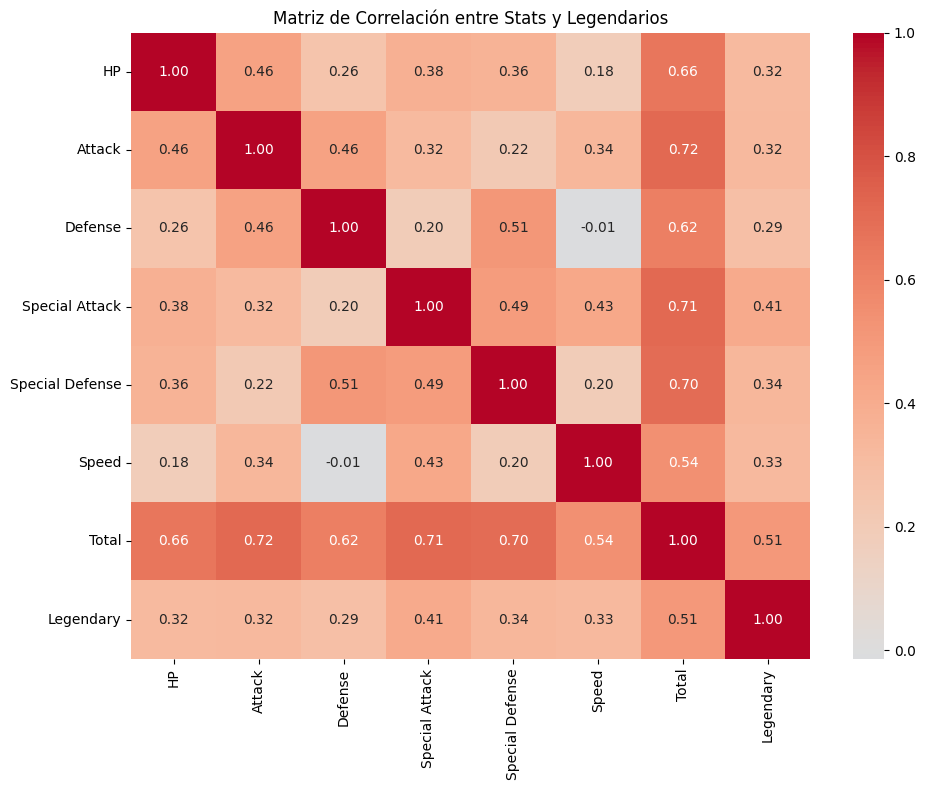

In [12]:
#Revisamos con un heatmap realmente si los legendarios tienen mas stats que los no legendarios:
cols_corr = ['HP', 'Attack', 'Defense', 'Special Attack', 'Special Defense', 'Speed', 'Total', 'Legendary']
corr_matrix = df_limpio[cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlación entre Stats y Legendarios')
plt.tight_layout()
plt.show()

In [13]:
#Special Attack = 0.41 es la stat individual con mayor correlación con Legendary, más que Attack, Defense, HP o Speed. Eso tiene sentido si lo vemos con el lore de los juegos y es que los legendarios tienden a ser pokemon más "especiales" que físicos.
#Speed = 0.33 tiene correlación casi nula con Defense (-0.01 entre ellas), lo que sugiere que son dimensiones completamente independientes del diseño de un pokemon. Esto es útil para ML porque features poco correlacionadas entre sí aportan información complementaria al modelo.
#Todas las stats están moderadamente correlacionadas con el total de stats (0.54–0.72), lo que es esperable porque Total es la suma de todas. Esto plantea una pregunta relevante para el modelo: 
#¿Conviene incluir Total como feature junto a las 6 stats individuales, o es redundante? Incluirlo puede hacer que el modelo haga trampa" apoyándose casi exclusivamente en Total e ignorando el patrón de distribución entre stats. 
#Decidimos que vale la pena probar ambas versiones.

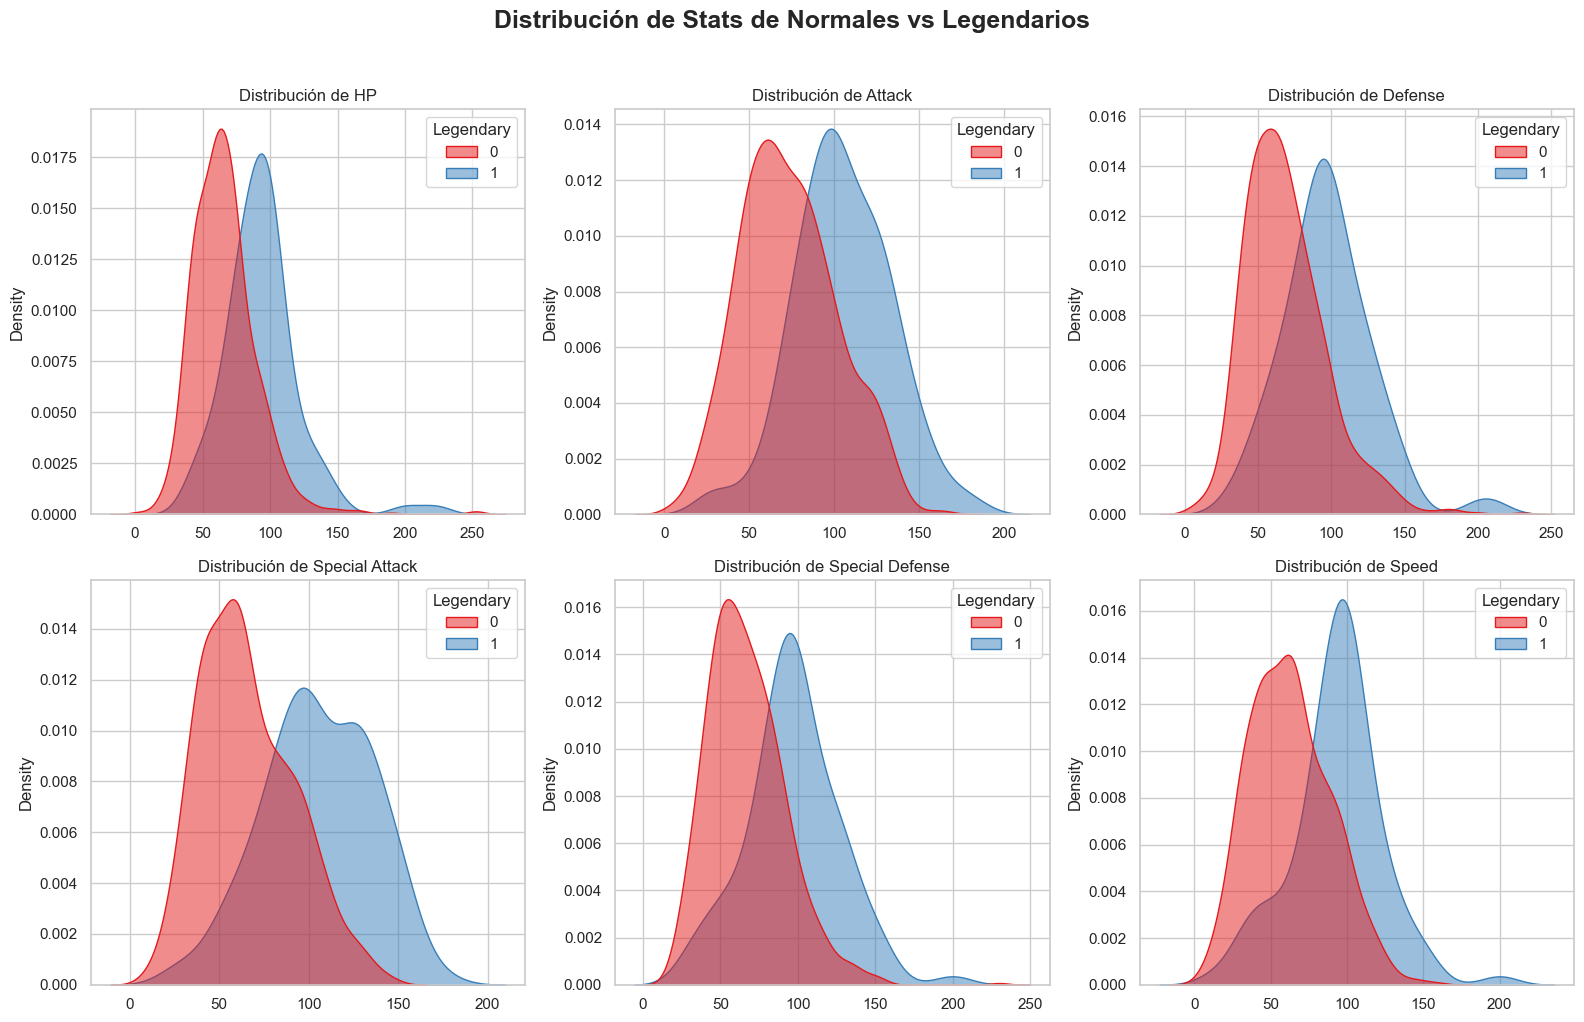

In [14]:
#Ahora, lo último que veremos de EDA para complementar el proyecto es los siguientes 3 bloques, primero usaremos el total individual por stat para ver la distribucion con legendarios y no legendary, ya que si usamos el total, estas se pueden solapar craendo confusion o no dejandolo del todo claro.
sns.set_theme(style="whitegrid")
stats = ['HP', 'Attack', 'Defense', 'Special Attack', 'Special Defense', 'Speed']

#Para todo, armamos una figura grande con 6 subgraficos (2 filas y 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución de Stats de Normales vs Legendarios', fontsize=18, fontweight='bold', y=1.02)

#Usamos un ciclo for para dibujar cada stat en su cuadrito correspondiente:
for i, stat in enumerate(stats):
    fila = i // 3
    columna = i % 3
    #Usamos kdeplot para ver la "montañita" (curva de densidad) de los datos, y ver como se relacionan las stats.
    sns.kdeplot(data=df_limpio, x=stat, hue='Legendary', fill=True, 
                ax=axes[fila, columna], common_norm=False, palette='Set1', alpha=0.5)
    axes[fila, columna].set_title(f'Distribución de {stat}', fontsize=12)
    axes[fila, columna].set_xlabel('')
plt.tight_layout()
plt.show()

Al observar las curvas de densidad para cada stat por separado, es evidente que los pokemon legendarios (área azul) tienden a concentrar sus valores más hacia la derecha en comparación a los pokemon normales (área roja), lo que nos muestra un mayor poder total en general. Sin embargo, el hallazgo más importante es el alto nivel de solapamiento entre ambas distribuciones, por ejemplo, un pokemon normal puede alcanzar fácilmente los 100 puntos de ataque o defensa, igualando la media de los legendarios. Esto justifica directamente la necesidad de utilizar modelos de ML ya que una sola stat no basta para clasificar a un legendario. El modelo deberá aprender a identificar la combinación simultánea de estas para lograr una predicción verdadeera.

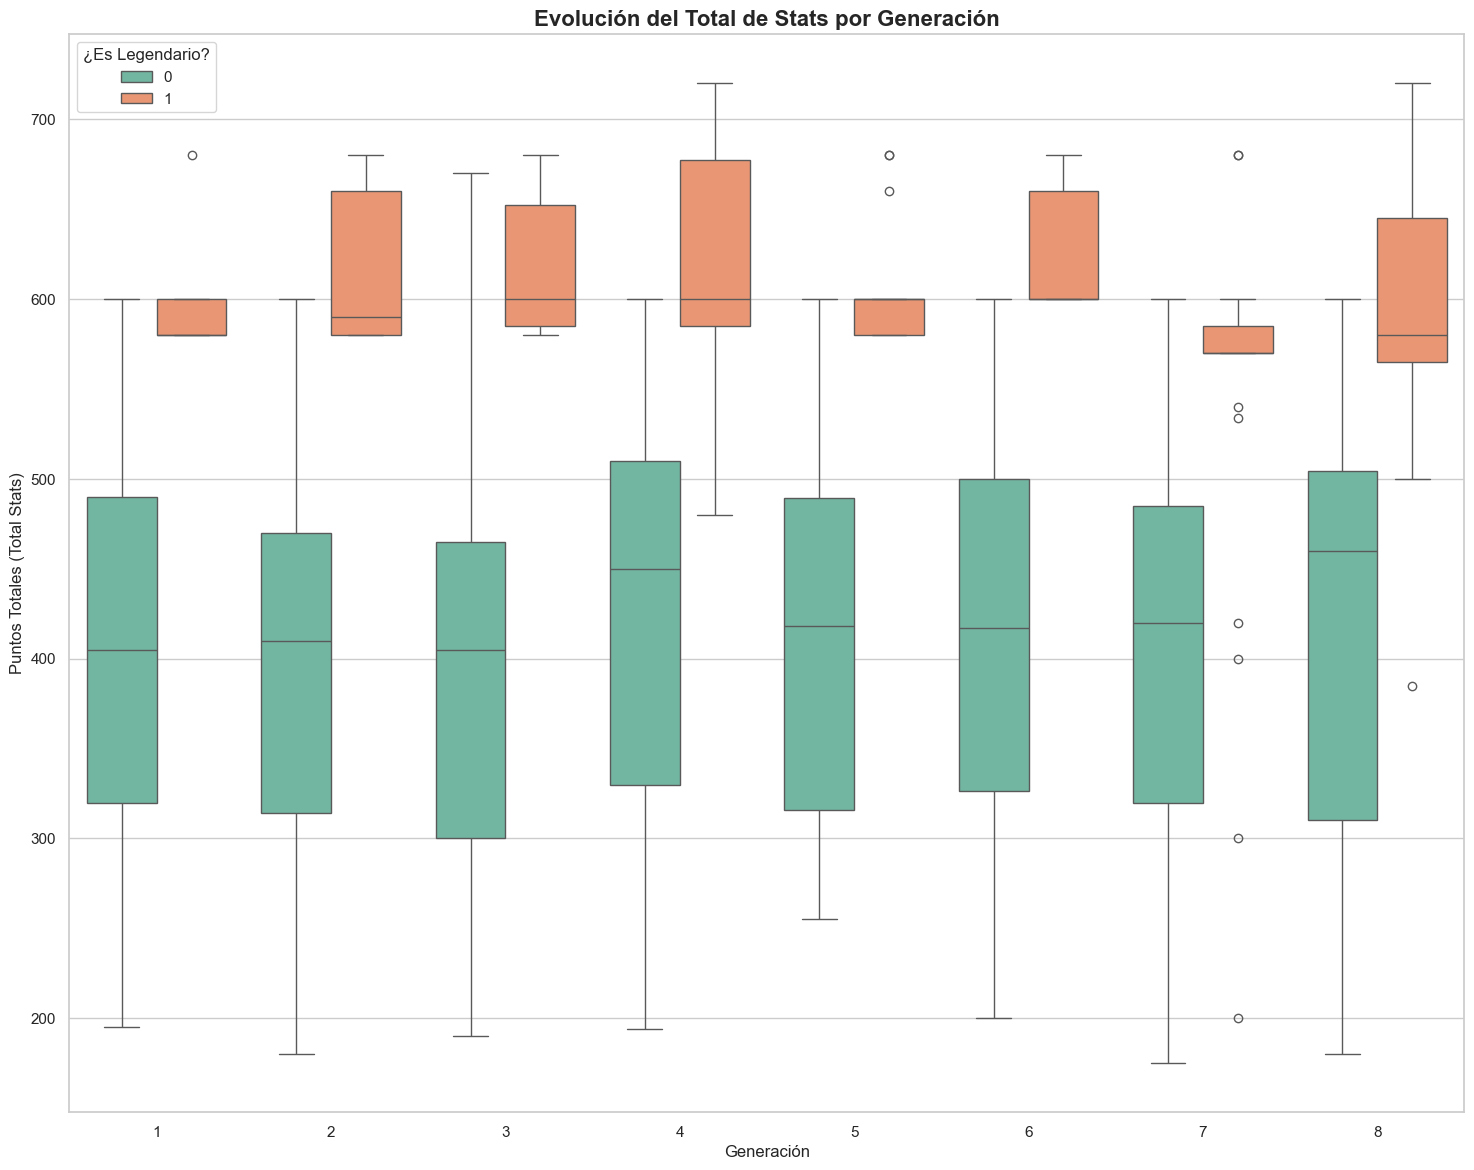

In [15]:
#Ahora en penultimo lugar, haremos un boxplot por generacion y legendarios y no legendarios, así podemos estudiar que generación está más "rota", es decir, la que sus pokemon tienen mas stats.
plt.figure(figsize=(18, 14)) #Tuve que hacer el tamaño varias veces para que la leyenda no estorbara
sns.boxplot(data=df_limpio, x='Generation', y='Total', hue='Legendary', palette='Set2')
plt.title('Evolución del Total de Stats por Generación', fontsize=16, fontweight='bold')
plt.xlabel('Generación', fontsize=12)
plt.ylabel('Puntos Totales (Total Stats)', fontsize=12)
plt.legend(title='¿Es Legendario?', loc='upper left')
plt.show()

El boxplot nos permite validar si nuestro modelo podrá generalizar sus predicciones a futuras generaciones (como la 9 con la que compararemos al final o una futura 10). Otra cosa que podemos observar es una notable estabilidad en el diseño del juego ya que a pesar del paso de los años y generaciones, la mediana del total de estadísticas de los pokemon legendarios se ha mantenido firmemente en torno a la barrera de los 600 puntos, sin mostrar una inflación desproporcionada de poder y por otro lado, los pokemon normales mantienen una mediana constante entre los 400 y 450 puntos, esto dado a que las "reglas matemáticas" que definen a un legendario son estables en el tiempo, por lo que podemos concluir que un modelo entrenado con datos de las generaciones 1 a la 8 debería ser sumamente robusto y útil para clasificar pokemon nuevos.

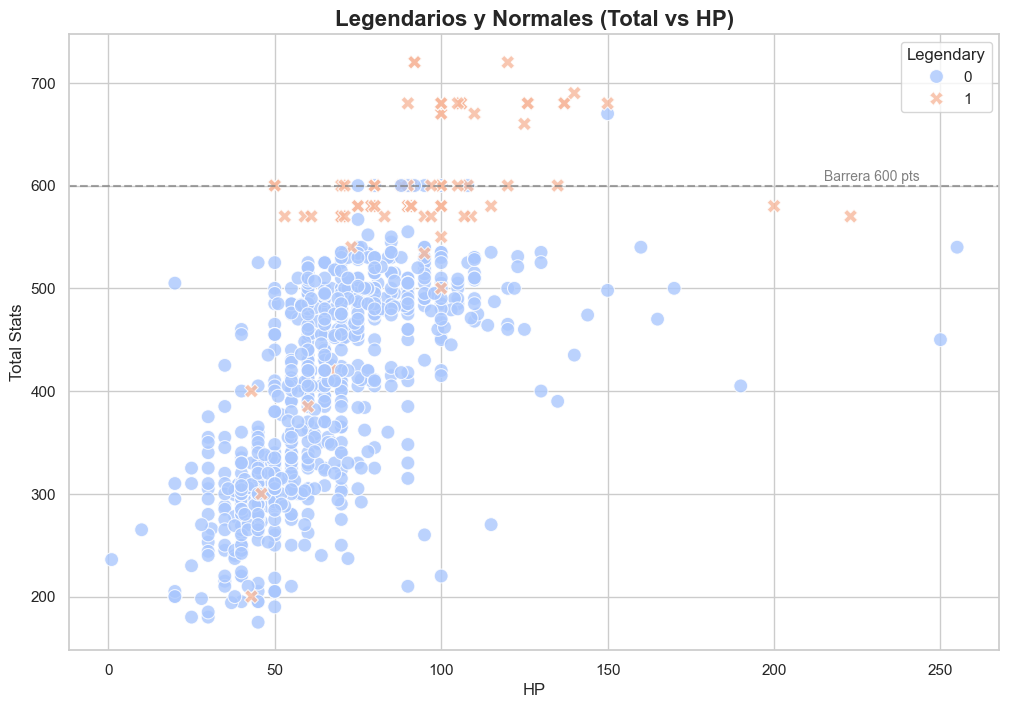

In [16]:
#Finalmente, para tereminar el EDA, lo que haremos es ver los pseudo-legendarios, que como su nombre lo dice, no son legendarios, pero aun asi, tienen stats muy altas.
#Para ello haremos un scatter con una separacion en los 600 puntos, donde por lo general están los legendarios, a excepción de algunos casos que están justo en los 600 o por debajo.
#Como referencia usaremos el total vs HP, pero podría ser con cualquier otra stat, ya que lo que realmente nos importa es ver la cantidad de puntitos sobre los 600.
#Algunos de estos legendarios que mencionabamos antes son Cosmog con 200 puntos totales, Cosmoem su evolución con 400, o Phione con 480, entre otros casos que existen como Kubfu, que si bien es la primera evolución de una bestia competitiva como Urshifu, no deja de ser un legendario bajo los 600.
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_limpio, x='HP', y='Total', hue='Legendary', 
                style='Legendary', s=100, palette='coolwarm', alpha=0.8)

#Tiramos la línea horizontal imaginaria en los 600 puntos para marcar la "barrera" que suelen tener los legendarios, y así visualizar mejor cuáles no legendarios se acercan o superan esa barrera.
plt.axhline(y=600, color='gray', linestyle='--', alpha=0.7)
plt.text(x=df_limpio['HP'].max() - 40, y=605, s='Barrera 600 pts', color='gray', fontsize=10)
plt.title('Legendarios y Normales (Total vs HP)', fontsize=16, fontweight='bold')
plt.xlabel('HP', fontsize=12)
plt.ylabel('Total Stats', fontsize=12)
plt.show()

Aquí se ve de forma clara el por qué no podemos simplemente hacer trampa y programar una regla que diga: "Si tiene 600 puntos o más, es Legendario". Si hiciéramos eso, el gráfico nos muestra que cometeríamos dos errores garrafales, en primer lugar, hay muchos pokemon normales que superean los 600 puntos, lo que los dejaría clasificados como legendarios, siendo esto totalmente falso (Aunque algunos por la historia y lo que representan en el fandom deberian serlo). Y en segundo lugar, es que dejariamos afuera a legendarios como los que se mencionaron antes (Phione, Cosmog, Cosmoem, entre otros) ya que son legendarios, pero no superan ni se acercan a la barrerea de los 600 puntos totales de stats.
Por lo que podriamos decir que esta barrera invisible de los 600 puntos es la razón de ser del proyecto, ya que con knn o random forest podemos lograr que se crucen las stats al mismo tiempo haciendo asi que el modelo pueda separar los pseudo-legendarios de los realmente legendarios (exceptuando casos como los ya mencionados, claro).

In [17]:
# Importaciones para el modelo 
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [18]:
#DEFINICIÓN DE EXPERIMENTOS (FEATURES Y TARGET)

feature_sets = {
'Con Total': ['HP', 'Attack', 'Defense', 'Special Attack', 'Special Defense', 'Speed', 'Total'],
    'Sin Total': ['HP', 'Attack', 'Defense', 'Special Attack', 'Special Defense', 'Speed']
}

y = df_limpio['Legendary']

In [19]:
#SPLIT ESTRATIFICADO DE DATOS (80/20)

splits = {}
for fs_nombre, features in feature_sets.items():
    X = df_limpio[features]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    splits[fs_nombre] = (X, X_train, X_test, y_train, y_test)

print("Splits generados con éxito para ambos experimentos")

Splits generados con éxito para ambos experimentos


In [20]:
#CONFIGURACIÓN DE PIPELINES Y VALIDACIÓN CRUZADA
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

diccionario_modelos = {'K-Nearest Neighbors': pipe_knn, 'Random Forest': pipe_rf}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [21]:
#EVALUACIÓN INICIAL CON VALIDACIÓN CRUZADA (CV)

for exp_nombre, (X, X_train, X_test, y_train, y_test) in splits.items():
    print(f"\n--- EXPERIMENTO: {exp_nombre} ---")
    for mod_nombre, pipeline in diccionario_modelos.items():
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
        print(f"{mod_nombre} -> Accuracy promedio en CV: {scores.mean():.2%}")


--- EXPERIMENTO: Con Total ---
K-Nearest Neighbors -> Accuracy promedio en CV: 94.42%
Random Forest -> Accuracy promedio en CV: 96.66%

--- EXPERIMENTO: Sin Total ---
K-Nearest Neighbors -> Accuracy promedio en CV: 93.72%
Random Forest -> Accuracy promedio en CV: 93.45%


En el Experimento con total el Random Forest llega a un 96.66%. Es un número altísimo porque, tal como sospechaban, al darle la columna Total, el modelo hace un poco de trampa y se apoya mucho en que los legendarios casi siempre tienen más de 580 o 600 puntos totales.

En el Experimento sin total el rendimiento baja un poquito (93.72% en KNN y 93.45% en Random Forest). Significa que quitándole el Total, los modelos siguen siendo potentes (sobre el 93%), pero ahora están obligados a aprender combinaciones reales de estadísticas individuales (como la relación entre Ataque Especial y Velocidad).


  Features: Con Total

  [K-Nearest Neighbors]
  Accuracy : 96.11%
  F1 CV    : 0.713 ± 0.057
               precision    recall  f1-score   support

No Legendario       0.96      0.99      0.98       162
   Legendario       0.92      0.67      0.77        18

     accuracy                           0.96       180
    macro avg       0.94      0.83      0.88       180
 weighted avg       0.96      0.96      0.96       180



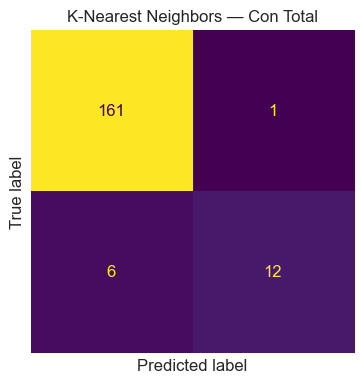


  [Random Forest]
  Accuracy : 98.33%
  F1 CV    : 0.875 ± 0.036
               precision    recall  f1-score   support

No Legendario       0.99      0.99      0.99       162
   Legendario       0.94      0.89      0.91        18

     accuracy                           0.98       180
    macro avg       0.96      0.94      0.95       180
 weighted avg       0.98      0.98      0.98       180



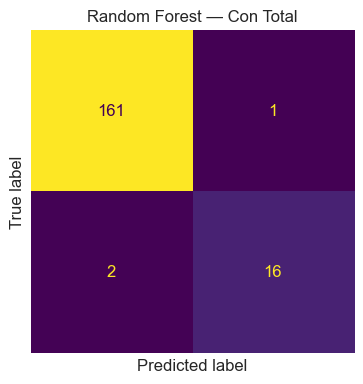


  Features: Sin Total

  [K-Nearest Neighbors]
  Accuracy : 95.56%
  F1 CV    : 0.670 ± 0.064
               precision    recall  f1-score   support

No Legendario       0.96      0.99      0.98       162
   Legendario       0.92      0.61      0.73        18

     accuracy                           0.96       180
    macro avg       0.94      0.80      0.85       180
 weighted avg       0.95      0.96      0.95       180



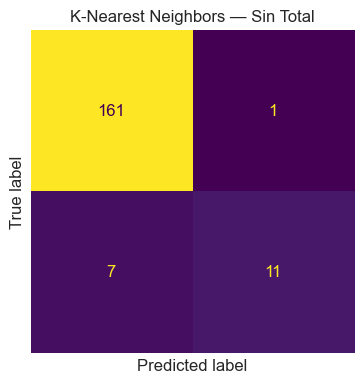


  [Random Forest]
  Accuracy : 95.00%
  F1 CV    : 0.601 ± 0.060
               precision    recall  f1-score   support

No Legendario       0.95      0.99      0.97       162
   Legendario       0.91      0.56      0.69        18

     accuracy                           0.95       180
    macro avg       0.93      0.77      0.83       180
 weighted avg       0.95      0.95      0.94       180



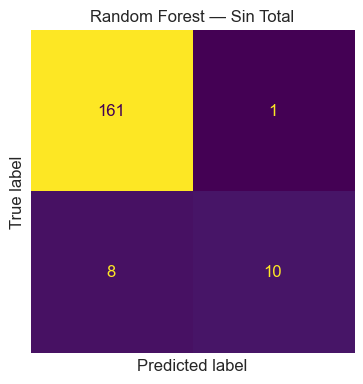

In [22]:
#Entrenamiento del modelo:
for fs_nombre, (X, X_train, X_test, y_train, y_test) in splits.items():

    print(f"\n{'='*50}")
    print(f"  Features: {fs_nombre}")
    print(f"{'='*50}")

    for nombre, modelo in diccionario_modelos.items():
        modelo.fit(X_train, y_train)
        predicciones = modelo.predict(X_test)
        scores_cv = cross_val_score(modelo, X, y, cv=cv, scoring='f1')

        print(f"\n  [{nombre}]")
        print(f"  Accuracy : {accuracy_score(y_test, predicciones)*100:.2f}%")
        print(f"  F1 CV    : {scores_cv.mean():.3f} ± {scores_cv.std():.3f}")
        print(classification_report(y_test, predicciones,
                                    target_names=['No Legendario', 'Legendario']))

        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_test, predicciones,
            display_labels=['No Legendario', 'Legendario'],
            ax=ax, colorbar=False
        )
        ax.set_title(f'{nombre} — {fs_nombre}')
        for _, spine in ax.spines.items():
             spine.set_visible(False)
             ax.set_xticks([])
             ax.set_yticks([])
        plt.tight_layout()
        plt.show()

In [24]:
#Como Random Forest fue nuestro mejor modelo, hacemos lo siguiente para el proximo "experimento":
#Reentrenamos y guardamos:
fs_nombre = 'Con Total'
X, X_train, X_test, y_train, y_test = splits[fs_nombre]

mejor_modelo = pipe_rf  # el pipeline de Random Forest
mejor_modelo.fit(X_train, y_train)

print("Modelo listo:", mejor_modelo)

Modelo listo: Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])


In [26]:
#Para poner a prueba el modelo usaremos un nuevo dataframe hecho a mano, con unos 15 pokemon, algunos legendarios y otros no, con sus respectivas stats, para ver si el modelo los clasifica correctamente.
#Para este ejercicio omitiremos los pokemon paradox, ya que suelen tener stats muy altas y al igual que las Mega o formas regionales, no son formas base de los mismos pokemon.
#Sin embargo, incluiremos uno un poco "pillería", que es Palafin Hero Form, que sigue siendo el mismo pokemon, ya que su forma cambia solo al ponerlo al combate al inicio y luego cambiarlo con "Flip turn" o manualmente para volverlo a poner activando su habilidad.
#Este "truco" para el modelo, es válido dado que el pokemon en sí no necesita objetos para tener una nueva forma ni es una forma regional o una "paradoja" (pasado o futuro).
nuevos_pokemon = pd.DataFrame([
    {'Pokedex No.': 1014, 'Name': 'Okidogi',  'Type': 'Poison', 'Other Type': 'Fighting', 'HP': 88, 'Attack': 128, 'Defense': 115, 'Special Attack': 58, 'Special Defense': 86, 'Speed': 80, 'Total': 555, 'Generation': 9, 'Legendary': 1},
    {'Pokedex No.': 1015, 'Name': 'Munkidori',  'Type': 'Poison', 'Other Type': 'Psychic', 'HP': 88, 'Attack': 75, 'Defense': 66, 'Special Attack': 130, 'Special Defense': 90, 'Speed': 106, 'Total': 555, 'Generation': 9, 'Legendary': 1},
    {'Pokedex No.': 908, 'Name': 'Mewscarada',  'Type': 'Grass', 'Other Type': 'Dark', 'HP': 76, 'Attack': 110, 'Defense': 70, 'Special Attack': 81, 'Special Defense': 70, 'Speed': 123, 'Total': 530, 'Generation': 9, 'Legendary': 0},
    {'Pokedex No.': 911, 'Name': 'Skeleridge',  'Type': 'Fire', 'Other Type': 'Ghost', 'HP': 104, 'Attack': 75, 'Defense': 100, 'Special Attack': 110, 'Special Defense': 75, 'Speed': 66, 'Total': 530, 'Generation': 9, 'Legendary': 0},
    {'Pokedex No.': 914, 'Name': 'Quaquaval',  'Type': 'Water', 'Other Type': 'Fighting', 'HP': 85, 'Attack': 120, 'Defense': 80, 'Special Attack': 85, 'Special Defense': 75, 'Speed': 85, 'Total': 530, 'Generation': 9, 'Legendary': 0},
    {'Pokedex No.': 1018, 'Name': 'Archaludon',  'Type': 'Steel', 'Other Type': 'Dragon', 'HP': 90, 'Attack': 105, 'Defense': 130, 'Special Attack': 125, 'Special Defense': 65, 'Speed': 85, 'Total': 600, 'Generation': 9, 'Legendary': 0},
    {'Pokedex No.': 1019, 'Name': 'Hydrapple',  'Type': 'Grass', 'Other Type': 'Dragon', 'HP': 106, 'Attack': 80, 'Defense': 110, 'Special Attack': 120, 'Special Defense': 80, 'Speed': 44, 'Total': 540, 'Generation': 9, 'Legendary': 0},
    {'Pokedex No.': 1018, 'Name': 'Ogerpon Teal Mask',  'Type': 'Grass', 'Other Type': 'None', 'HP': 80, 'Attack': 120, 'Defense': 84, 'Special Attack': 60, 'Special Defense': 96, 'Speed': 110, 'Total': 550, 'Generation': 9, 'Legendary': 1},
    {'Pokedex No.': 1016, 'Name': 'Fezandipiti',  'Type': 'Poison', 'Other Type': 'Fairy', 'HP': 88, 'Attack': 91, 'Defense': 82, 'Special Attack': 70, 'Special Defense': 125, 'Speed': 99, 'Total': 555, 'Generation': 9, 'Legendary': 1},
    {'Pokedex No.': 998, 'Name': 'Baxcalibur',  'Type': 'Dragon', 'Other Type': 'Ice', 'HP': 115, 'Attack': 145, 'Defense': 92, 'Special Attack': 75, 'Special Defense': 86, 'Speed': 87, 'Total': 600, 'Generation': 9, 'Legendary': 0},
    {'Pokedex No.': 1001, 'Name': 'Wo-Chien',  'Type': 'Dark', 'Other Type': 'Grass', 'HP': 85, 'Attack': 85, 'Defense': 100, 'Special Attack': 95, 'Special Defense': 135, 'Speed': 70, 'Total': 570, 'Generation': 9, 'Legendary': 1},
    {'Pokedex No.': 1007, 'Name': 'Koraidon',  'Type': 'Fighting', 'Other Type': 'Dragon', 'HP': 100, 'Attack': 135, 'Defense': 115, 'Special Attack': 85, 'Special Defense': 100, 'Speed': 135, 'Total': 670, 'Generation': 9, 'Legendary': 1},
    {'Pokedex No.': 1008, 'Name': 'Miraidon',  'Type': 'Electric', 'Other Type': 'Dragon', 'HP': 100, 'Attack': 85, 'Defense': 100, 'Special Attack': 135, 'Special Defense': 115, 'Speed': 135, 'Total': 670, 'Generation': 9, 'Legendary': 1},
    {'Pokedex No.': 977, 'Name': 'Dondozo',  'Type': 'Water', 'Other Type': 'None', 'HP': 150, 'Attack': 100, 'Defense': 115, 'Special Attack': 65, 'Special Defense': 65, 'Speed': 35, 'Total': 530, 'Generation': 9, 'Legendary': 0},
    {'Pokedex No.': 964, 'Name': 'Palafin Hero Form',  'Type': 'Water', 'Other Type': 'None', 'HP': 100, 'Attack': 160, 'Defense': 97, 'Special Attack': 106, 'Special Defense': 87, 'Speed': 100, 'Total': 650, 'Generation': 9, 'Legendary': 0}
])

In [29]:
#Como nuestro modelo fue entrenado con el dataset limpio, tenemos que asegurarnos de que este nuevo dataframe tenga la misma estructura y columnas que el dataset original, para evitar errores al predecir.
#Para ello hacemos lo siguiente:
#Separar nombre para mostrarlos después
nombres = nuevos_pokemon['Name']
verdaderos = nuevos_pokemon['Legendary']

features_con_total = ['HP', 'Attack', 'Defense', 'Special Attack', 'Special Defense', 'Speed', 'Total']
features_sin_total = ['HP', 'Attack', 'Defense', 'Special Attack', 'Special Defense', 'Speed']

experimentos = {
    'Con Total': features_con_total,
    'Sin Total': features_sin_total
}

for exp_nombre, features in experimentos.items():
    print(f"\n{'='*50}")
    print(f"  Experimento: {exp_nombre}")
    print(f"{'='*50}")

    # Reentrenar con las features correctas
    X, X_train, X_test, y_train, y_test = splits[exp_nombre]
    pipe_rf.fit(X_train, y_train)

    X_nuevos = nuevos_pokemon[features]
    predicciones = pipe_rf.predict(X_nuevos)

    for nombre, pred, real in zip(nombres, predicciones, verdaderos):
        pred_label = '¡Legendario!' if pred == 1 else 'No Legendario'
        real_label = '¡Legendario!' if real == 1 else 'No Legendario'
        acierto    = '✅' if pred == real else '❌'
        print(f"{acierto} {nombre:25} → Predicho: {pred_label:15} | Real: {real_label}")


  Experimento: Con Total
❌ Okidogi                   → Predicho: No Legendario   | Real: ¡Legendario!
❌ Munkidori                 → Predicho: No Legendario   | Real: ¡Legendario!
✅ Mewscarada                → Predicho: No Legendario   | Real: No Legendario
✅ Skeleridge                → Predicho: No Legendario   | Real: No Legendario
✅ Quaquaval                 → Predicho: No Legendario   | Real: No Legendario
❌ Archaludon                → Predicho: ¡Legendario!    | Real: No Legendario
✅ Hydrapple                 → Predicho: No Legendario   | Real: No Legendario
❌ Ogerpon Teal Mask         → Predicho: No Legendario   | Real: ¡Legendario!
❌ Fezandipiti               → Predicho: No Legendario   | Real: ¡Legendario!
✅ Baxcalibur                → Predicho: No Legendario   | Real: No Legendario
✅ Wo-Chien                  → Predicho: ¡Legendario!    | Real: ¡Legendario!
✅ Koraidon                  → Predicho: ¡Legendario!    | Real: ¡Legendario!
✅ Miraidon                  → Predicho: ¡Leg

Tras haber hecho el experimento con un pequeño dataframe, vemos que acertó en más del 50% de los casos (Obtuvo 9 de 15 correctos) incluso con pocos datos como dijimos y además, confusos, ya que al poner pseudo-legendarios y legendarios con stats altas y bajas correspondiente, podría haber fallado más, sin embargo funcionó de manera bastante decente.